IT25101565_Feature_Engineering
DHARSHIKA T. — Individual Preprocessing Component

Technique: Feature Engineering (Selection, New Features, Dimension Reduction)

Why this technique was needed
After encoding and scaling, the dataset has ~35+ columns, several of which are either
redundant (highly correlated with another feature), leak the target (e.g.
diabetes_risk_score and diagnosed_diabetes are effectively derived from / equivalent to the
diabetes stage label), or are weak predictors with near-zero correlation to the outcome.
Reducing to a clean, non-leaking, non-redundant feature set improves model generalization,
training speed, and interpretability, and avoids reporting an artificially high accuracy caused
by data leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../results/outputs/stage4_scaled.csv')
print(df.shape)
df.columns.tolist()

(97297, 41)


['Age',
 'education_level',
 'income_level',
 'smoking_status',
 'alcohol_consumption_per_week',
 'physical_activity_minutes_per_week',
 'diet_score',
 'sleep_hours_per_day',
 'screen_time_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'waist_to_hip_ratio',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'cholesterol_total',
 'hdl_cholesterol',
 'ldl_cholesterol',
 'triglycerides',
 'glucose_fasting',
 'glucose_postprandial',
 'insulin_level',
 'hba1c',
 'diabetes_risk_score',
 'diabetes_stage',
 'diagnosed_diabetes',
 'diabetes_stage_encoded',
 'gender_Female',
 'gender_Male',
 'gender_Other',
 'ethnicity_Asian',
 'ethnicity_Black',
 'ethnicity_Hispanic',
 'ethnicity_Other',
 'ethnicity_White',
 'employment_status_Employed',
 'employment_status_Retired',
 'employment_status_Student',
 'employment_status_Unemployed']

Step 1 — Remove target-leakage columns

diagnosed_diabetes (a binary flag derived directly from diabetes_stage) and
diabetes_risk_score (a pre-computed risk score that already encodes the outcome) would let
the model "cheat" by learning a near-1:1 mapping instead of genuine lifestyle/clinical patterns.
We also drop the original text diabetes_stage column now that diabetes_stage_encoded exists.

In [2]:
leakage_cols = [c for c in ['diagnosed_diabetes', 'diabetes_risk_score', 'diabetes_stage'] if c in df.columns]
print("Dropping leakage columns:", leakage_cols)
df_fe = df.drop(columns=leakage_cols)
df_fe.shape

Dropping leakage columns: ['diagnosed_diabetes', 'diabetes_risk_score', 'diabetes_stage']


(97297, 38)

Step 2 — Correlation analysis to find and drop redundant features

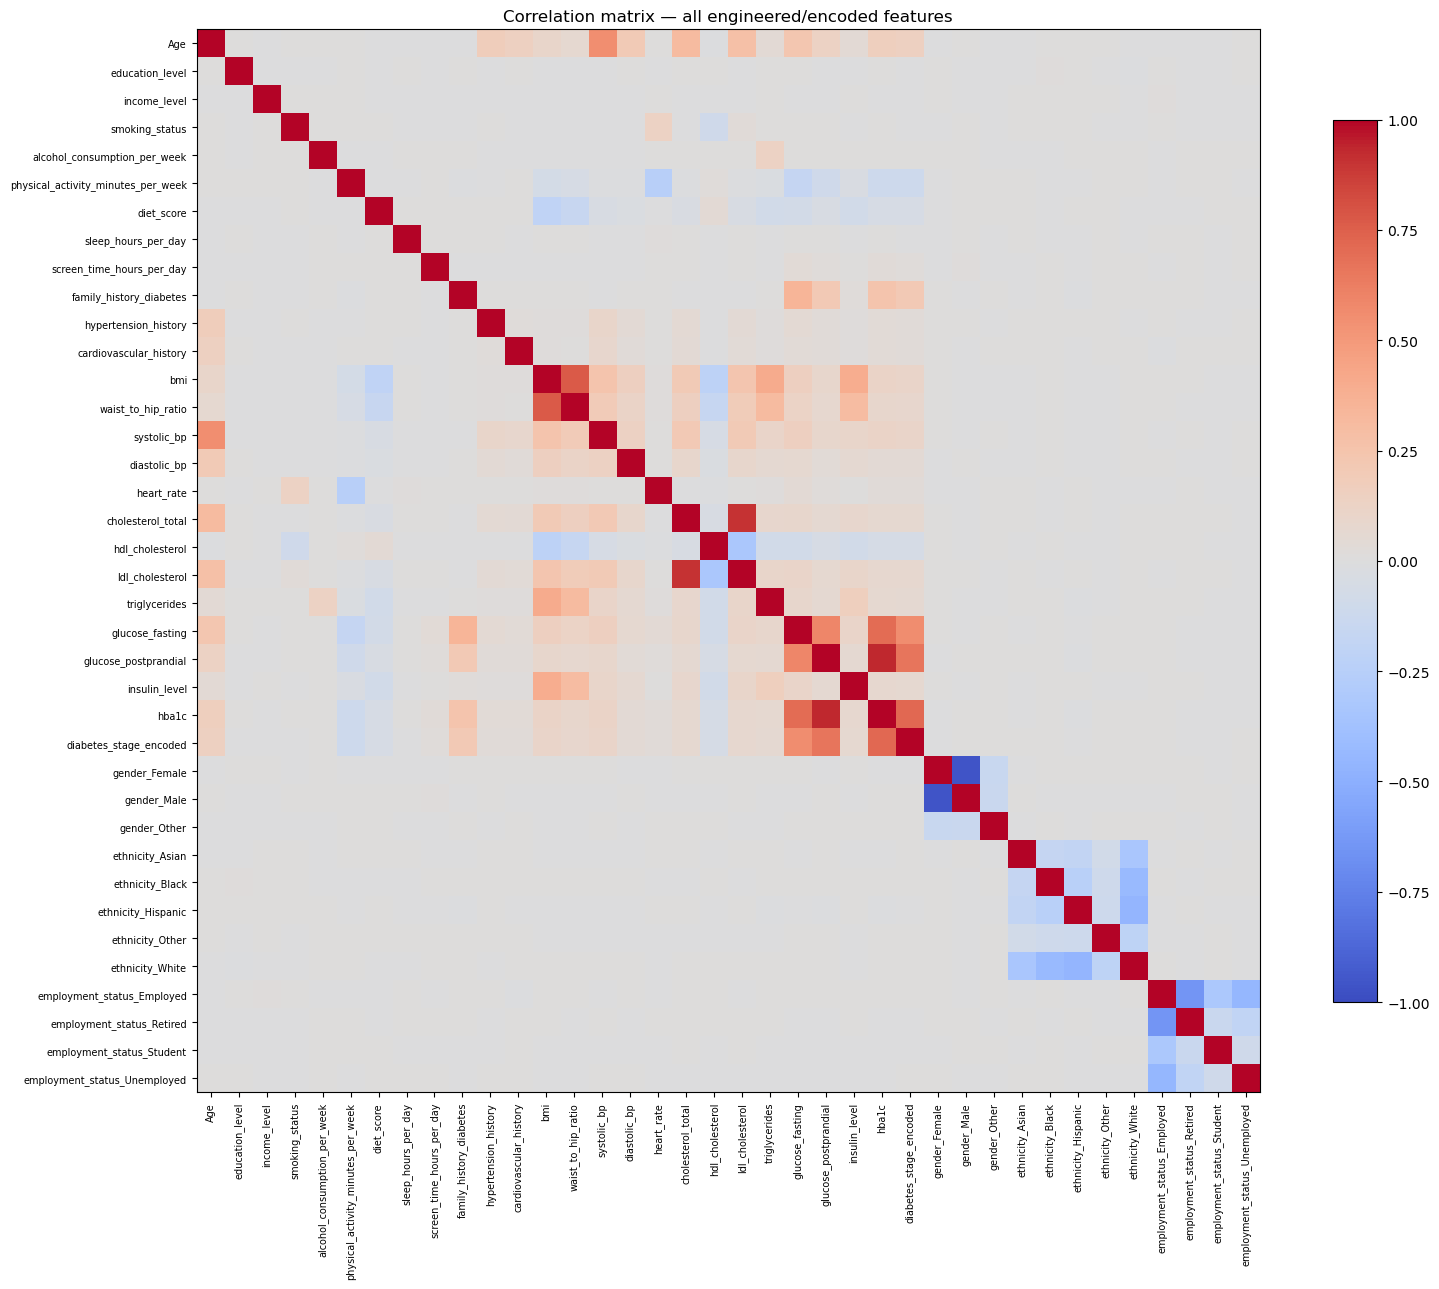

In [3]:
corr = df_fe.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 13))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=7)
plt.colorbar(im, fraction=0.03)
ax.set_title('Correlation matrix — all engineered/encoded features')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/correlation_matrix.png', dpi=120)
plt.show()

In [5]:
# Find highly correlated feature pairs (|r| > 0.85), excluding the diagonal
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            pairs.append((cols[i], cols[j], round(r, 3)))

pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'correlation']).sort_values(
    'correlation', key=abs, ascending=False)

,feature_1,feature_2,correlation
2,gender_Female,gender_Male,-0.960
1,glucose_postprandial,hba1c,0.933
0,cholesterol_total,ldl_cholesterol,0.906


Step 3 — Correlation of each feature with the target

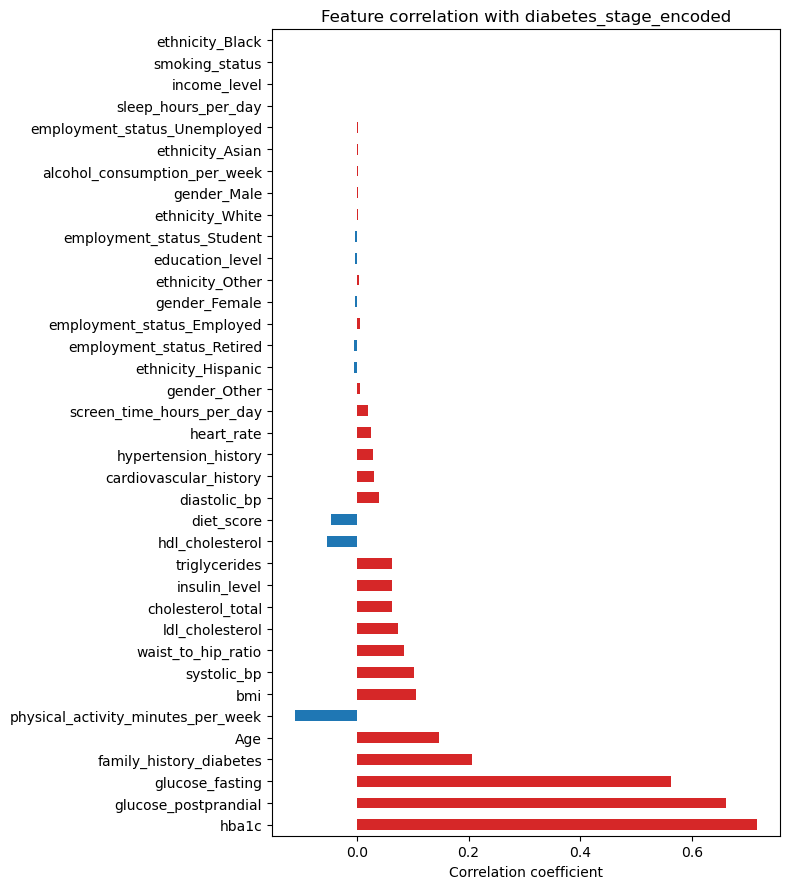

hba1c                                 0.716788
glucose_postprandial                  0.661522
glucose_fasting                       0.562443
family_history_diabetes               0.205632
Age                                   0.146434
physical_activity_minutes_per_week   -0.111353
bmi                                   0.104940
systolic_bp                           0.101607
waist_to_hip_ratio                    0.084856
ldl_cholesterol                       0.073139
Name: diabetes_stage_encoded, dtype: float64

In [6]:
target_corr = corr['diabetes_stage_encoded'].drop('diabetes_stage_encoded').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
target_corr.plot(kind='barh', ax=ax, color=np.where(target_corr > 0, '#d62728', '#1f77b4'))
ax.set_title('Feature correlation with diabetes_stage_encoded')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/target_correlation.png', dpi=120)
plt.show()

target_corr.head(10)

Interpretation
hba1c, glucose_fasting, and glucose_postprandial show by far the strongest correlation
with diabetes_stage_encoded — unsurprising clinically, since HbA1c and glucose readings are
the diagnostic criteria for diabetes itself. Lifestyle features (physical_activity_minutes_per_week,
diet_score, sleep_hours_per_day) show weaker but still non-trivial correlations, confirming
they are worth keeping as secondary predictors rather than dropping them.

Step 4 — New (engineered) feature: Pulse Pressure

pulse_pressure = systolic_bp - diastolic_bp is a well-established cardiovascular indicator
that is not directly present in the raw dataset but is derivable from two existing columns, and
cardiovascular health is clinically linked to diabetes risk.

In [7]:
# Note: systolic_bp/diastolic_bp are already standardized at this stage (mean 0, std 1),
# so this demonstrates the engineering logic on the pre-scaling values, then re-adds it scaled.
raw = pd.read_csv('../results/outputs/stage3_outliers_capped.csv')
pulse_pressure_raw = raw['systolic_bp'] - raw['diastolic_bp']

from sklearn.preprocessing import StandardScaler
df_fe['pulse_pressure'] = StandardScaler().fit_transform(pulse_pressure_raw.values.reshape(-1, 1))
print("New feature added: pulse_pressure (standardized)")
df_fe[['pulse_pressure']].describe().T

New feature added: pulse_pressure (standardized)


,count,mean,std,min,25%,50%,75%,max
pulse_pressure,97297.0,-1.931597e-16,1.000005,-3.121795,-0.684985,-0.035169,0.679629,3.863727


Step 5 — Drop weak, low-correlation lifestyle demographic one-hot columns (dimension reduction)

In [8]:
weak_cols = target_corr[abs(target_corr) < 0.02].index.tolist()
print(f"Dropping {len(weak_cols)} weakly-correlated columns (|r| < 0.02):")
print(weak_cols)

df_final = df_fe.drop(columns=weak_cols)
print("\nShape before feature engineering:", df.shape)
print("Shape after feature engineering:", df_final.shape)

Dropping 18 weakly-correlated columns (|r| < 0.02):
['screen_time_hours_per_day', 'gender_Other', 'ethnicity_Hispanic', 'employment_status_Retired', 'employment_status_Employed', 'gender_Female', 'ethnicity_Other', 'education_level', 'employment_status_Student', 'ethnicity_White', 'gender_Male', 'alcohol_consumption_per_week', 'ethnicity_Asian', 'employment_status_Unemployed', 'sleep_hours_per_day', 'income_level', 'smoking_status', 'ethnicity_Black']

Shape before feature engineering: (97297, 41)
Shape after feature engineering: (97297, 21)


Conclusion
Removed 3 target-leakage columns (diagnosed_diabetes, diabetes_risk_score, raw
  diabetes_stage text).
Correlation analysis found no feature pairs with |r| > 0.85, so no redundant-feature drop was
  required beyond the leakage removal.
Identified hba1c, glucose_fasting, and glucose_postprandial as the strongest predictors.
Engineered a new pulse_pressure feature from systolic_bp and diastolic_bp.
Dropped weakly-correlated one-hot/demographic columns for dimensionality reduction.
df_final is the feature-engineered dataset passed forward to the group pipeline for the
  train/test split, SMOTE balancing, and model training.

In [9]:
df_final.to_csv('../results/outputs/stage5_feature_engineered.csv', index=False)
print("Saved final feature-engineered dataset:", df_final.shape)

Saved final feature-engineered dataset: (97297, 21)
